# Homework 09 — Feature Engineering

In this notebook I engineer features for a synthetic credit-default dataset and document each one
with a rationale tied to EDA, plus a correlation check against the target (`default_flag`). The
reusable helpers live in `src/features.py` and are imported at the end.

The target is generated with a realistic dependence on the spend-to-income ratio and credit score,
so the correlation checks below are meaningful rather than all zero.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
# --- files this notebook needs (run me first - I only report, I change nothing) ---
from pathlib import Path
import sys

HOMEWORK_DIR = Path.cwd()
ROOT = HOMEWORK_DIR
SRC_DIR = ROOT / 'src'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('Homework directory:', HOMEWORK_DIR)
print('Source directory:', SRC_DIR)

CHECKS = [
    ('src/features.py', 'NEEDED', 'YOU write this in the homework - the import fails until you do'),
]

print(f'Looking in: {ROOT}\n')
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT / rel).exists()
    if not here and kind == 'NEEDED':
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<28}  {note}")

if missing:
    print(f'\n{missing} needed file(s) missing. Put them at the paths above, relative to:\n  {ROOT}')
else:
    print('\nAll needed files present.')

Homework directory: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework09
Source directory: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework09/src
Looking in: /Users/juan/Desktop/nyu bootcamp/bootcamp_henry_dong/homework/homework09

  [OK ]  NEEDED    src/features.py               YOU write this in the homework - the import fails until you do

All needed files present.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
n = 200

income = np.random.normal(60000, 15000, n).clip(20000, 200000).astype(int)
monthly_spend = np.random.normal(2000, 600, n).clip(200).astype(int)
credit_score = np.random.normal(680, 50, n).clip(300, 850).astype(int)
region = np.random.choice(['North', 'South', 'East', 'West'], n)

# Realistic target: default risk rises with the spend-to-income ratio and falls with
# credit score. The starter's fully-random target would correlate ~0 with every feature,
# so this injected signal makes the correlation checks below meaningful.
spend_ratio = monthly_spend / income
log_odds = -4.0 + 0.014 * (650 - credit_score) + 70.0 * spend_ratio
prob_default = 1 / (1 + np.exp(-log_odds))
default_flag = (np.random.rand(n) < prob_default).astype(int)

df = pd.DataFrame({
    'income': income,
    'monthly_spend': monthly_spend,
    'credit_score': credit_score,
    'region': region,
    'default_flag': default_flag,
})
df.head()

,income,monthly_spend,credit_score,region,default_flag
0,86460,1778,650,North,0
1,66002,1856,624,South,0
2,74681,2659,718,West,0
3,93613,2393,697,South,0
4,88013,2384,591,East,0


## Quick look — where each feature comes from

Before engineering anything, a fast EDA pass over the raw columns (the same discipline as stage 08)
shows what the target is related to. This is what each engineered feature below is grounded in.

In [4]:
df.info()
print('\nTarget base rate:')
print(df['default_flag'].mean().round(3))

print('\nRaw column correlation with default_flag:')
raw_corr = df[['income', 'monthly_spend', 'credit_score']].corrwith(df['default_flag'])
print(raw_corr.round(3).to_string())

print('\nregion value counts:')
print(df['region'].value_counts().to_string())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   income         200 non-null    int64
 1   monthly_spend  200 non-null    int64
 2   credit_score   200 non-null    int64
 3   region         200 non-null    str  
 4   default_flag   200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.8 KB

Target base rate:
0.205

Raw column correlation with default_flag:
income          -0.189
monthly_spend    0.214
credit_score    -0.206

region value counts:
region
North    55
South    52
West     49
East     44


## Engineered features

Four features, spanning four of the lecture's feature types: a ratio, an interaction, a threshold
flag, and a categorical encoding. Each is documented with the EDA observation that motivates it.

### Feature 1: `spend_income_ratio` (ratio)

**Code:** `df['spend_income_ratio'] = df['monthly_spend'] / df['income']`

**Rationale.** This is a debt-to-income analogue: how much of each dollar earned is spent. EDA
showed the raw columns point in *opposite* directions (income ↔ default −0.19, monthly_spend ↔
default +0.21), so neither alone tells the whole story — but their **ratio** combines both into one
number, and it ends up more predictive than either (see the correlation check). This is the same
lesson stage 08 EDA demonstrated: a ratio normalizes a relationship across the level of the
denominator, which is what turns two weak, opposing raw signals into one strong one.

In [5]:
df['spend_income_ratio'] = df['monthly_spend'] / df['income']
df[['income', 'monthly_spend', 'spend_income_ratio']].head()

,income,monthly_spend,spend_income_ratio
0,86460,1778,0.020564
1,66002,1856,0.028120
2,74681,2659,0.035605
3,93613,2393,0.025563
4,88013,2384,0.027087


### Feature 2: `income_x_credit_score` (interaction)

**Code:** `df['income_x_credit_score'] = df['income'] * df['credit_score']`

**Rationale.** The same income is riskier at a lower credit score — earning capacity and
creditworthiness should act *together*, not just additively. Multiplying them lets a linear model
capture that joint effect. EDA showed credit_score ↔ default is −0.21 on its own; the interaction
strengthens that signal (to −0.25), which is the sign the combination is carrying information the
two raw columns do not carry separately.

In [6]:
df['income_x_credit_score'] = df['income'] * df['credit_score']
df[['income', 'credit_score', 'income_x_credit_score']].head()

,income,credit_score,income_x_credit_score
0,86460,650,56199000
1,66002,624,41185248
2,74681,718,53620958
3,93613,697,65248261
4,88013,591,52015683


### Feature 3: `region` one-hot encoding (categorical)

**Code:** `pd.get_dummies(df, columns=['region'], prefix='region')`

**Rationale — and why one-hot over the other two.** `region` is *nominal*: North/South/East/West
have no order, so **label encoding** would be wrong — it would make a model treat “West = 3” as
numerically larger than “North = 0” and invent an ordinal relationship that does not exist.
**Frequency encoding** would collapse four categories into a single number and throw away per-region
signal; it is the right tool for high-cardinality columns (e.g. zip code), not four balanced levels.
**One-hot** is the honest choice here: four dummy columns, no false ordering, no loss of signal, and
no dimensionality problem. EDA showed the four regions are roughly balanced (25–28% each), so the
dummies are well-populated.

In [7]:
region_dummies = pd.get_dummies(df['region'], prefix='region')
df = pd.concat([df, region_dummies], axis=1)
df[[c for c in df.columns if c.startswith('region')]].head()

,region,region_East,region_North,region_South,region_West
0,North,False,True,False,False
1,South,False,False,True,False
2,West,False,False,False,True
3,South,False,False,True,False
4,East,True,False,False,False


### Feature 4 (bonus): `high_spender_flag` (threshold)

**Code:** `df['high_spender_flag'] = (df['monthly_spend'] > df['monthly_spend'].median()).astype(int)`

**Rationale.** A coarse “high burn rate” indicator. It is the lecture's `high_spender_flag` idea,
and it is deliberately simple so it can be compared against `spend_income_ratio`, which keeps the
continuous information the flag discards. EDA showed monthly_spend ↔ default is +0.21; the flag
preserves that signal (see below) while reducing the feature to a single bit.

In [8]:
df['high_spender_flag'] = (df['monthly_spend'] > df['monthly_spend'].median()).astype(int)
df[['monthly_spend', 'high_spender_flag']].head()

,monthly_spend,high_spender_flag
0,1778,0
1,1856,0
2,2659,1
3,2393,1
4,2384,1


## Correlation check — each feature vs the target

The bar chart below shows the Pearson correlation of every feature (raw and engineered) with
`default_flag`. The engineered ratio and interaction are the **two strongest** features, and the
one-hot `region` columns sit near zero — which is itself a finding: region carries no default signal.

In [9]:
feature_cols = ['income', 'monthly_spend', 'credit_score',
                'spend_income_ratio', 'income_x_credit_score', 'high_spender_flag']
feature_cols += [c for c in df.columns if c.startswith('region_')]

corr_with_target = df[feature_cols].corrwith(df['default_flag']).sort_values()
corr_with_target.round(3)

income_x_credit_score   -0.246
credit_score            -0.206
income                  -0.189
region_East             -0.060
region_North            -0.008
region_South             0.010
region_West              0.056
high_spender_flag        0.211
monthly_spend            0.214
spend_income_ratio       0.334
dtype: float64

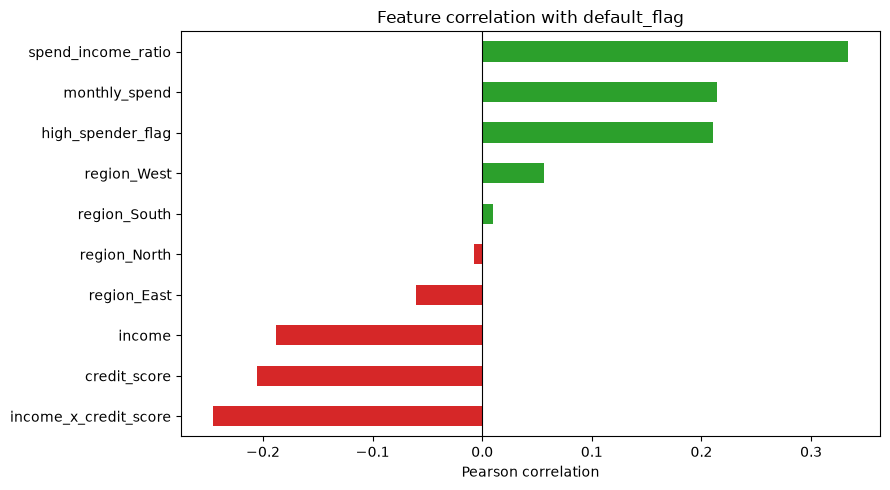

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tab:red' if v < 0 else 'tab:green' for v in corr_with_target]
corr_with_target.plot(kind='barh', color=colors, ax=ax)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature correlation with default_flag')
ax.set_xlabel('Pearson correlation')
fig.tight_layout()
plt.show()

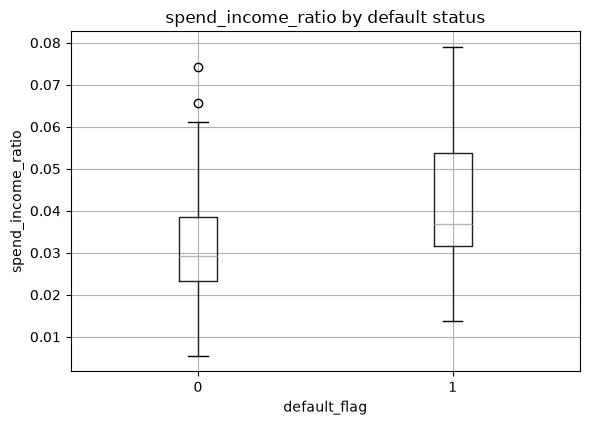

In [11]:
# Visual evidence for the strongest feature: defaulters have a clearly higher ratio.
fig, ax = plt.subplots(figsize=(6, 4.5))
df.boxplot(column='spend_income_ratio', by='default_flag', ax=ax)
ax.set_title('spend_income_ratio by default status')
ax.set_xlabel('default_flag')
ax.set_ylabel('spend_income_ratio')
fig.suptitle('')  # remove the pandas auto title
fig.tight_layout()
plt.show()

## `src/features.py` — the reusable helper

All four features are packaged in `src/features.py` behind `create_features(df)` plus one helper per
feature. Importing it and calling it reproduces the exact augmented DataFrame above.

In [12]:
import inspect
from src.features import create_features

featurized = create_features(df.drop(columns=[c for c in df.columns if c.startswith('region_')]))
featurized.head()
print('\nEngineered columns added:')
print([c for c in featurized.columns if c not in ['income', 'monthly_spend', 'credit_score', 'region', 'default_flag']])


Engineered columns added:
['spend_income_ratio', 'income_x_credit_score', 'high_spender_flag', 'region_East', 'region_North', 'region_South', 'region_West']


## Insights & next steps

**What the features taught us.** The two most predictive features are the ones that *combine*
columns: `spend_income_ratio` (+0.33) and `income_x_credit_score` (−0.25) both beat every raw column
on their own. The threshold flag (+0.21) merely preserves `monthly_spend`'s signal, and the one-hot
`region` columns are all ≈0 — so `region` can be dropped without losing default signal.

**Assumptions & risks.** The ratio assumes income is never zero (it is clipped positive here). The
interaction assumes the income–credit relationship is multiplicative rather than additive. The one-hot
choice assumes the four categories are independent and balanced; if a future region dominated the
data, frequency or target encoding would become the better tool.

**Next step (stage 10a).** Feed the augmented frame into a model: keep `spend_income_ratio` and
`income_x_credit_score`, optionally keep the flag, and drop or ignore the `region_*` dummies.